# Thematic Graphs and Polarization

This notebook constructs and visualizes the thematic graphs that represent the
structural relationships between political actors and discussion topics. It produces
five complementary representations:

- User-topic bipartite network: which politician talks about which topic and how intensely.
- Politician similarity network: edge weight equals agenda similarity between actors,
  derived from the Jensen-Shannon distance.
- Topic correlation network: two topics are connected when their temporal share series
  are significantly correlated across the actor pool.
- Stance-polarization heatmap: for each politician-topic pair, the dominant stance
  and the positivity index.
- Temporal network snapshots: how the politician similarity network changes across
  three political periods.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

TOPIC_LABELS = [
    'Economy and Employment',
    'Welfare, Housing and Social Policy',
    'National Politics and Governance',
    'International Affairs',
    'Immigration and Security',
    'Rights and Equality',
    'Other',
]

TOPIC_COLORS = {
    'Economy and Employment':              '#4C72B0',
    'Welfare, Housing and Social Policy':  '#55A868',
    'National Politics and Governance':    '#C44E52',
    'International Affairs':               '#8172B2',
    'Immigration and Security':            '#CCB974',
    'Rights and Equality':                 '#64B5CD',
    'Other':                               '#8C8C8C',
}

STANCE_COLORS = {
    'Against':  '#C44E52',
    'Unclear':  '#8C8C8C',
    'Neutral':  '#DDA85C',
    'In favor': '#4C72B0',
}

POLITICIAN_ORDER = ['sanchezcastejon', 'NunezFeijoo', 'Santi_ABASCAL', 'Yolanda_Diaz_']
POLITICIAN_LABELS = {
    'sanchezcastejon': 'Sanchez',
    'NunezFeijoo':     'Feijoo',
    'Santi_ABASCAL':   'Abascal',
    'Yolanda_Diaz_':   'Y. Diaz',
}
POLITICIAN_COLORS = {
    'sanchezcastejon': '#C44E52',
    'NunezFeijoo':     '#4C72B0',
    'Santi_ABASCAL':   '#55A868',
    'Yolanda_Diaz_':   '#8172B2',
}

COMMON_START = pd.Timestamp('2022-04-23')
COMMON_END   = pd.Timestamp('2025-01-21')

## Load data

In [2]:
df = pd.read_csv('classified_all_tweets_final_v2_clean.csv', parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

df_common = df[(df['date'] >= COMMON_START) & (df['date'] <= COMMON_END)].copy()

print(f'Full corpus  : {len(df):,} tweets')
print(f'Common period: {len(df_common):,} tweets  '
      f'({COMMON_START.date()} → {COMMON_END.date()})')
print(f'Politicians  : {sorted(df["politician"].unique())}')

Full corpus  : 11,866 tweets
Common period: 9,908 tweets  (2022-04-23 → 2025-01-21)
Politicians  : ['NunezFeijoo', 'Santi_ABASCAL', 'Yolanda_Diaz_', 'sanchezcastejon']


## User-topic bipartite network

A bipartite graph divides nodes into two disjoint sets that cannot be connected
to each other within the same set. Here the two sets are political actors on
the left and topic categories on the right. An edge is drawn between a politician
and a topic whenever the politician assigned at least 2% of their tweets to that
category during the common period. Edges below that threshold are hidden to keep
the figure readable.

Edge width and transparency are both scaled to the percentage of tweets, so the
thicker and more opaque an edge, the more dominant that topic is for that actor.
Percentage labels appear on edges that exceed 10% to mark the most salient
actor-topic relationships. Node size for politicians is proportional to their
total tweet volume during the common period; topic nodes are drawn at a uniform
size.

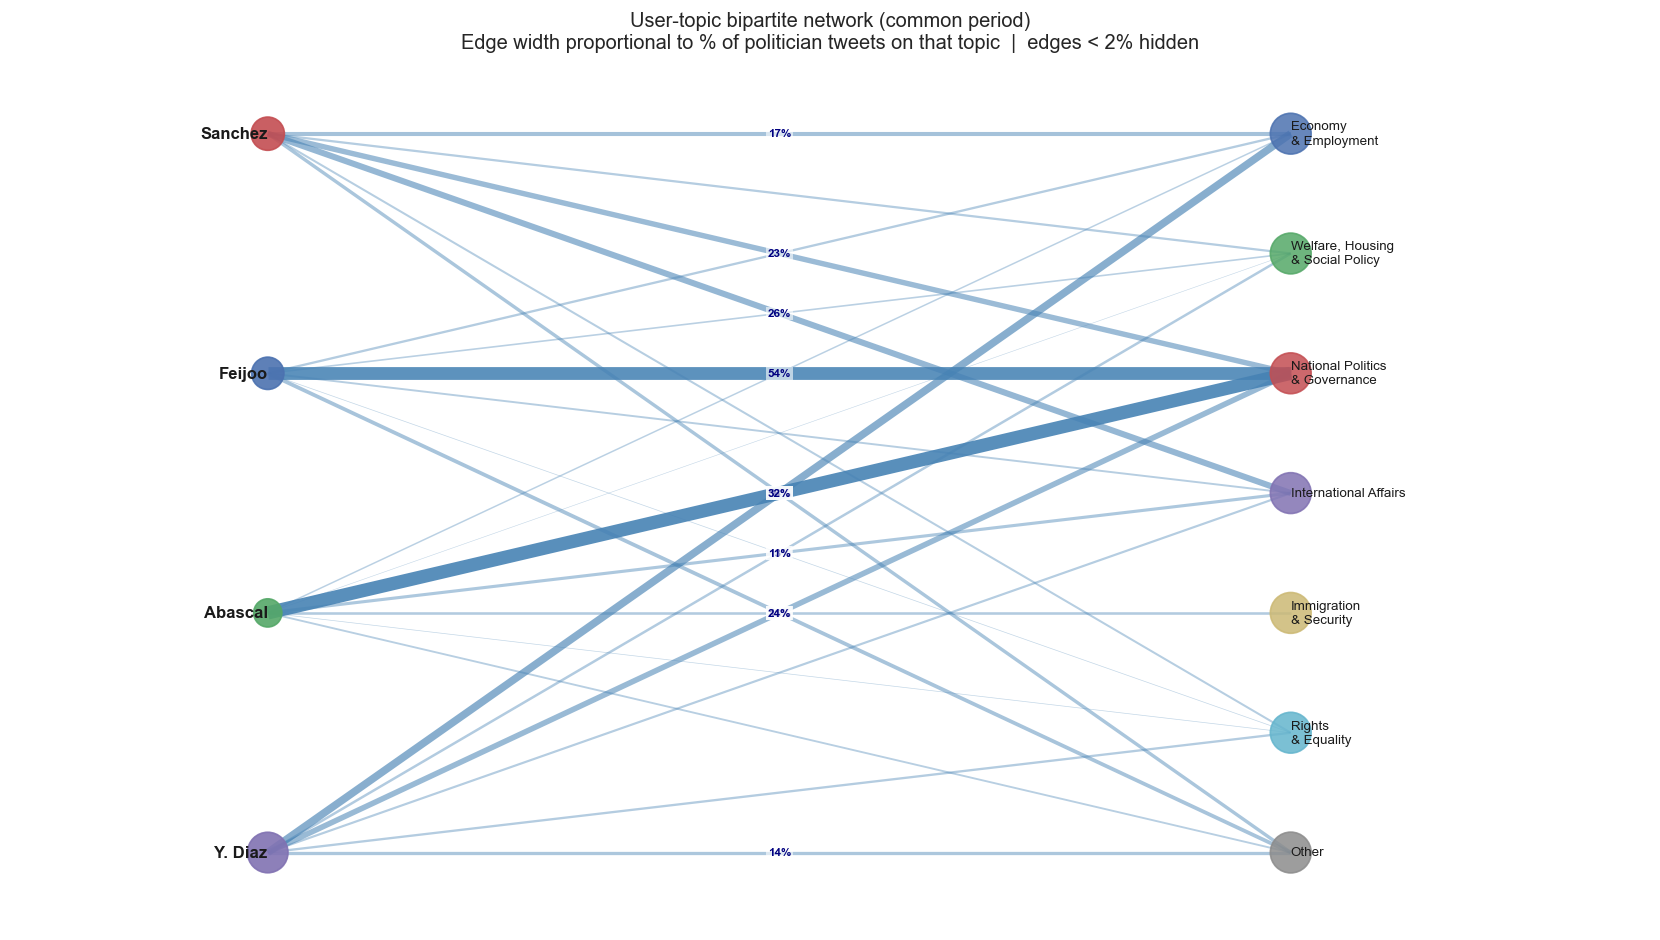


Actor-topic share matrix (%):
topic            Economy and Employment  Welfare, Housing and Social Policy  National Politics and Governance  International Affairs  Immigration and Security  Rights and Equality  Other
politician                                                                                                                                                                                
NunezFeijoo                         9.8                                 7.0                              54.2                    8.2                       1.9                  2.9   16.1
Santi_ABASCAL                       6.3                                 2.3                              56.4                   13.2                      10.9                  2.9    7.9
Yolanda_Diaz_                      32.1                                10.6                              23.6                    9.2                       0.7                  9.8   13.9
sanchezcastejon                   

In [3]:
# --- Build edge table ---
actor_topic_pct = (
    pd.crosstab(df_common['politician'], df_common['topic'], normalize='index') * 100
).reindex(columns=TOPIC_LABELS)

MIN_EDGE_PCT = 2.0   # hide edges below this threshold

B = nx.Graph()

pol_nodes   = POLITICIAN_ORDER
topic_nodes = TOPIC_LABELS

B.add_nodes_from(pol_nodes,   bipartite=0)
B.add_nodes_from(topic_nodes, bipartite=1)

tweet_counts = df_common['politician'].value_counts()

for pol in pol_nodes:
    for topic in topic_nodes:
        w = actor_topic_pct.loc[pol, topic]
        if w >= MIN_EDGE_PCT:
            B.add_edge(pol, topic, weight=w)

# --- Layout: politicians on the left, topics on the right ---
pos = {}
n_pol   = len(pol_nodes)
n_topic = len(topic_nodes)
for i, p in enumerate(pol_nodes):
    pos[p] = (0.0, 1 - i / (n_pol - 1))
for j, t in enumerate(topic_nodes):
    pos[t] = (1.0, 1 - j / (n_topic - 1))

# --- Figure ---
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_axis_off()

# Node sizes
pol_sizes   = [tweet_counts.get(p, 100) / 6 for p in pol_nodes]
topic_sizes = [600] * len(topic_nodes)

nx.draw_networkx_nodes(B, pos, nodelist=pol_nodes,
                       node_color=[POLITICIAN_COLORS[p] for p in pol_nodes],
                       node_size=pol_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=topic_nodes,
                       node_color=[TOPIC_COLORS[t] for t in topic_nodes],
                       node_size=topic_sizes, alpha=0.85, ax=ax)

# Labels
pol_label_dict   = {p: POLITICIAN_LABELS[p] for p in pol_nodes}
topic_label_dict = {t: t.replace(' and ', '\n& ') for t in topic_nodes}

nx.draw_networkx_labels(B, pos, labels=pol_label_dict,
                        font_size=10, font_weight='bold',
                        horizontalalignment='right', ax=ax)
nx.draw_networkx_labels(B, pos, labels=topic_label_dict,
                        font_size=8, horizontalalignment='left', ax=ax)

# Edges
edges = B.edges(data=True)
edge_list    = [(u, v) for u, v, d in edges]
edge_weights = [d['weight'] for u, v, d in edges]
max_w        = max(edge_weights)
edge_widths  = [w / max_w * 8 for w in edge_weights]
edge_alphas  = [0.3 + 0.6 * (w / max_w) for w in edge_weights]

for (u, v), width, alpha in zip(edge_list, edge_widths, edge_alphas):
    nx.draw_networkx_edges(B, pos, edgelist=[(u, v)],
                           width=width, alpha=alpha,
                           edge_color='steelblue', ax=ax)

# Edge weight annotations (only strong edges >= 10%)
for u, v, d in B.edges(data=True):
    if d['weight'] >= 10:
        mid = ((pos[u][0] + pos[v][0]) / 2,
               (pos[u][1] + pos[v][1]) / 2)
        ax.text(mid[0], mid[1], f"{d['weight']:.0f}%",
                ha='center', va='center', fontsize=7,
                color='navy', fontweight='bold',
                bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

ax.set_title(
    'User-topic bipartite network (common period)\n'
    'Edge width proportional to % of politician tweets on that topic  |  edges < 2% hidden',
    fontsize=12)
ax.set_xlim(-0.25, 1.35)
plt.tight_layout()
plt.show()

print('\nActor-topic share matrix (%):')
print(actor_topic_pct.round(1).to_string())

The figure shows a bipartite network connecting political actors with the topics they discuss during the common period. Nodes on the left represent politicians, while nodes on the right represent topic categories. Edge width is proportional to the percentage of each politician's tweets assigned to a given topic. Edges below 2% are hidden to reduce visual clutter.

The graph shows that National Politics and Governance is the central topic in the discussion structure, especially for Núñez Feijóo and Santiago Abascal. Both actors devote more than half of their tweets to this category, with 54.2% for Núñez Feijóo and 56.4% for Santiago Abascal. This suggests that their communication is strongly focused on national political conflict, government activity, institutional issues, laws, parties and electoral competition.

The graph also reveals clear differences between actors. Núñez Feijóo presents the most concentrated profile around National Politics and Governance, with a secondary presence of Other (16.1%), Economy and Employment (9.8%) and International Affairs (8.2%). This pattern is consistent with a discourse mainly oriented towards institutional opposition and national political debate.

Santiago Abascal also shows a dominant connection with National Politics and Governance, but his profile differs from Núñez Feijóo because he has stronger links with International Affairs (13.2%) and Immigration and Security (10.9%). This indicates that, although his agenda is also centered on national politics, it includes a more visible emphasis on security, immigration and international issues.

In contrast, Yolanda Díaz displays a more socio-economic profile. Her strongest topic is Economy and Employment (32.1%), followed by National Politics and Governance (23.6%), Other (13.9%), Welfare, Housing and Social Policy (10.6%) and Rights and Equality (9.8%). This suggests that her communication is less concentrated on institutional confrontation and more oriented towards labour, social policy and rights-related issues.

Pedro Sánchez also shows a more diversified agenda. His main topic is International Affairs (25.8%), followed by National Politics and Governance (22.9%), Economy and Employment (17.3%), Other (14.4%), Welfare, Housing and Social Policy (9.5%) and Rights and Equality (8.7%). Compared with the opposition actors, his discourse is less dominated by national political conflict and includes a stronger international component, which is consistent with the communicative role of a head of government.

In summary, the network shows two broad patterns. Núñez Feijóo and Santiago Abascal are strongly connected to National Politics and Governance, indicating a more concentrated agenda around national political confrontation. Yolanda Díaz and Pedro Sánchez show more diversified thematic profiles, with greater weight given to socio-economic issues, international affairs, welfare and rights. Therefore, the user-topic network provides an interpretable view of how each political actor contributes differently to the discussion structure.

## Politician similarity network

Each node represents a political actor. Edges connect all pairs of actors;
edge width and colour are both scaled to the agenda similarity between the
two actors, computed as one minus the Jensen-Shannon distance between their
topic distributions. A thicker, warmer edge indicates that the two politicians
devote similar proportions of their tweets to each topic; a thinner, cooler
edge indicates that their agendas diverge.

The Jensen-Shannon distance is a symmetric, bounded measure derived from the
Kullback-Leibler divergence. It equals zero when two distributions are identical
and one when they share no probability mass on any category. Using base-2
logarithms bounds the distance in the interval [0, 1], making it directly
comparable across actor pairs.

The spring layout positions nodes by treating similarity as an attractive force.
The k parameter controls the preferred distance between nodes in the absence of
edges; a value of 1.5 spreads the four actors enough to make the edge labels
readable while still reflecting the pull of within-bloc similarity. The random
seed is fixed so the layout is reproducible.

The figure on the right shows the same information as a symmetric heatmap of
raw JSD distances, which allows precise numerical comparison of all six pairs.

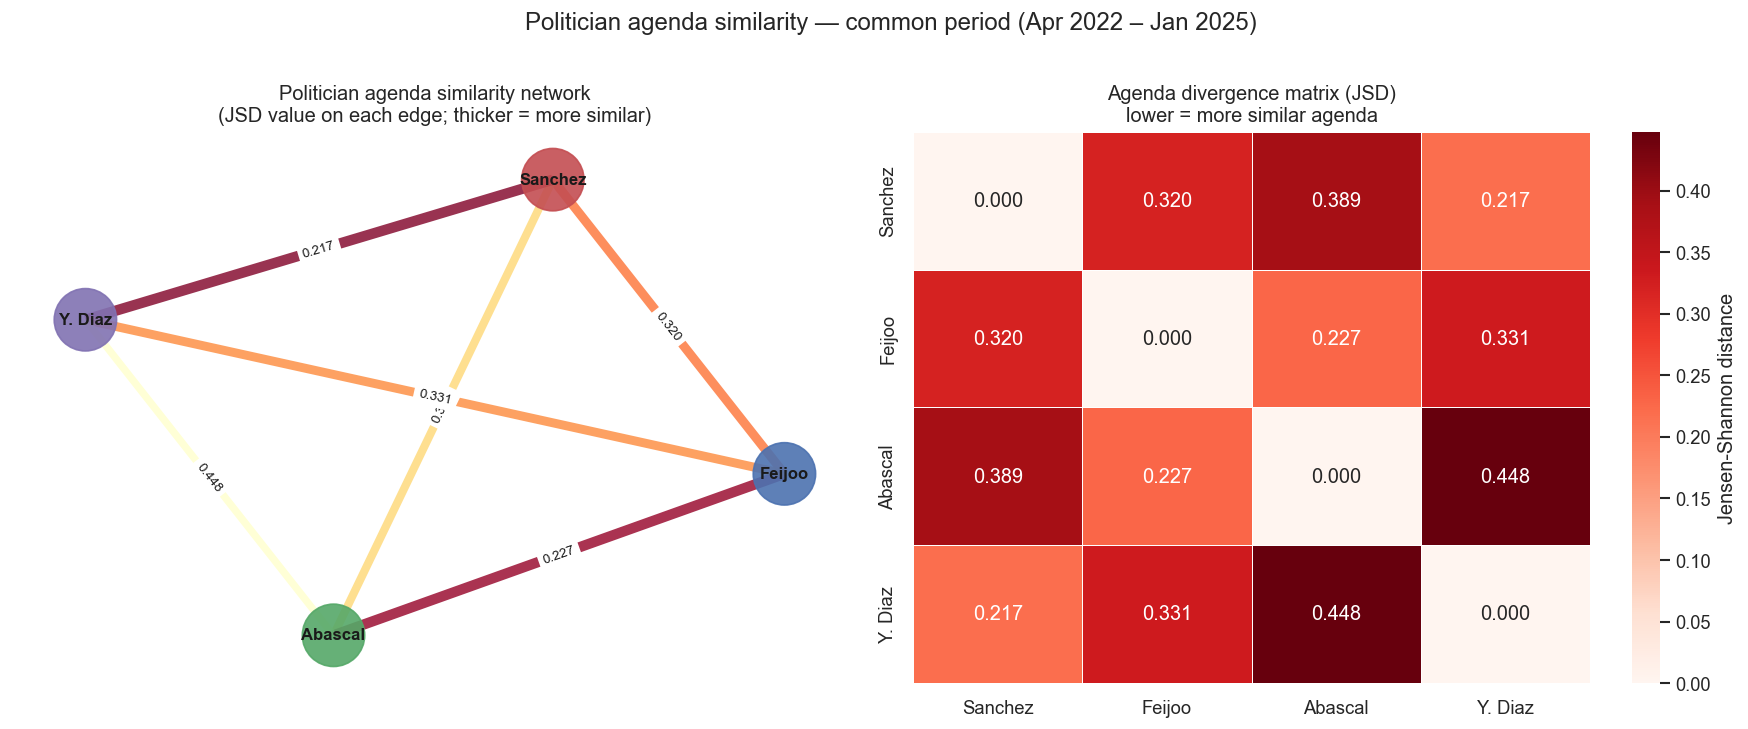


Pairs ranked by agenda similarity (JSD — lower = more similar):
Actor A Actor B   JSD  Similarity
Sanchez Y. Diaz 0.217       0.783
 Feijoo Abascal 0.227       0.773
Sanchez  Feijoo 0.320       0.680
 Feijoo Y. Diaz 0.331       0.669
Sanchez Abascal 0.389       0.611
Abascal Y. Diaz 0.448       0.552


In [4]:
# --- JSD matrix (common period) ---
actors = POLITICIAN_ORDER
P = actor_topic_pct.loc[actors].values / 100

jsd_matrix = pd.DataFrame(index=actors, columns=actors, dtype=float)
for i, a in enumerate(actors):
    for j, b in enumerate(actors):
        jsd_matrix.loc[a, b] = jensenshannon(P[i], P[j], base=2)

sim_matrix = 1 - jsd_matrix  # similarity in [0, 1]

# --- Build graph (all pairs; weight = similarity) ---
G_sim = nx.Graph()
G_sim.add_nodes_from(actors)
for i in range(len(actors)):
    for j in range(i + 1, len(actors)):
        G_sim.add_edge(actors[i], actors[j],
                       weight=float(sim_matrix.iloc[i, j]),
                       jsd=float(jsd_matrix.iloc[i, j]))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: network diagram
ax = axes[0]
pos_sim = nx.spring_layout(G_sim, weight='weight', seed=42, k=1.5)

node_colors = [POLITICIAN_COLORS[p] for p in G_sim.nodes()]
node_labels = {p: POLITICIAN_LABELS[p] for p in G_sim.nodes()}
edge_weights_sim = [d['weight'] for _, _, d in G_sim.edges(data=True)]
edge_widths_sim  = [w * 8 for w in edge_weights_sim]

nx.draw_networkx_nodes(G_sim, pos_sim, node_color=node_colors,
                       node_size=1400, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_sim, pos_sim, labels=node_labels,
                        font_size=10, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_sim, pos_sim,
                       width=edge_widths_sim,
                       edge_color=edge_weights_sim,
                       edge_cmap=plt.cm.YlOrRd,
                       alpha=0.8, ax=ax)

# Edge labels: JSD distance
edge_labels_sim = {(u, v): f'{d["jsd"]:.3f}' for u, v, d in G_sim.edges(data=True)}
nx.draw_networkx_edge_labels(G_sim, pos_sim, edge_labels=edge_labels_sim,
                             font_size=8, ax=ax)

ax.set_axis_off()
ax.set_title('Politician agenda similarity network\n'
             '(JSD value on each edge; thicker = more similar)')

# Right: heatmap of JSD matrix
ax2 = axes[1]
labels_short = [POLITICIAN_LABELS[a] for a in actors]
sns.heatmap(jsd_matrix.astype(float),
            xticklabels=labels_short, yticklabels=labels_short,
            annot=True, fmt='.3f', cmap='Reds',
            linewidths=0.5, linecolor='white',
            vmin=0, cbar_kws={'label': 'Jensen-Shannon distance'}, ax=ax2)
ax2.set_title('Agenda divergence matrix (JSD)\nlower = more similar agenda')

plt.suptitle('Politician agenda similarity — common period (Apr 2022 – Jan 2025)',
             y=1.01)
plt.tight_layout()
plt.show()

print('\nPairs ranked by agenda similarity (JSD — lower = more similar):')
pairs = []
for i in range(len(actors)):
    for j in range(i+1, len(actors)):
        pairs.append({
            'Actor A': POLITICIAN_LABELS[actors[i]],
            'Actor B': POLITICIAN_LABELS[actors[j]],
            'JSD':     round(float(jsd_matrix.iloc[i,j]), 3),
            'Similarity': round(float(sim_matrix.iloc[i,j]), 3),
        })
print(pd.DataFrame(pairs).sort_values('JSD').to_string(index=False))

This figure compares the thematic agendas of the four political actors during the common period, from April 2022 to January 2025. The comparison is based on the distribution of topics in each actor's tweets. Jensen-Shannon distance is used to measure how different two topic distributions are. Lower JSD values indicate more similar agendas, while higher values indicate greater divergence.

The closest pair is Sánchez and Yolanda Díaz, with a JSD of 0.217 and a similarity score of 0.783. This means that their topic distributions are the most similar among all actor pairs. This result is consistent with the previous user-topic network, where both actors showed more diversified agendas and relatively stronger links with socio-economic, welfare, rights-related and institutional topics.

The second closest pair is Feijóo and Abascal, with a JSD of 0.227 and a similarity score of 0.773. This indicates that the two opposition actors have very similar thematic profiles. Both concentrate a large share of their communication on National Politics and Governance, which explains their high agenda similarity.

The remaining pairs show greater thematic distance. Sánchez and Feijóo have an intermediate JSD of 0.320, while Feijóo and Yolanda Díaz show a similar level of divergence, with a JSD of 0.331. These values suggest partial overlap, but also clear differences in agenda focus.

The greatest distance appears between Abascal and Yolanda Díaz, with a JSD of 0.448 and a similarity score of 0.552. This is the most divergent pair in the network. The result reflects their different thematic priorities: Abascal gives more weight to National Politics and Governance, Immigration and Security, and International Affairs, while Yolanda Díaz gives more weight to Economy and Employment, Welfare, Housing and Social Policy, and Rights and Equality.

The network therefore again reveals two main agenda clusters. One cluster is formed by Sánchez and Yolanda Díaz, whose agendas are closer to the government and socio-economic policy space. The other cluster is formed by Feijóo and Abascal, whose agendas are more concentrated around national political confrontation. The heatmap confirms the same structure, showing lower distances within these two pairs and higher distances across actors from different political blocs.

## Topic correlation network

Two topics are connected if their monthly share series are significantly
correlated at the corpus level over the common period. Each series is computed
by aggregating all four actors' tweets in each month and calculating the
percentage of that month's total tweets belonging to each topic.

Correlation is measured with the Pearson coefficient, which quantifies the
linear relationship between two time series on a scale from -1 to 1. A value
close to 1 means that both topics rise and fall together (co-salience); a value
close to -1 means that when one topic is prominent the other tends to recede
(substitution). The threshold of |r| >= 0.30 retains only relationships with
at least a moderate linear association. The p-value threshold of 0.05 ensures
that only correlations unlikely to arise by chance in a 33-month series are
shown. The Other category is excluded because it is a residual bucket whose
content is heterogeneous rather than thematically coherent.

Blue edges represent positive correlation; red edges represent negative
correlation. Edge width is proportional to the absolute value of r.

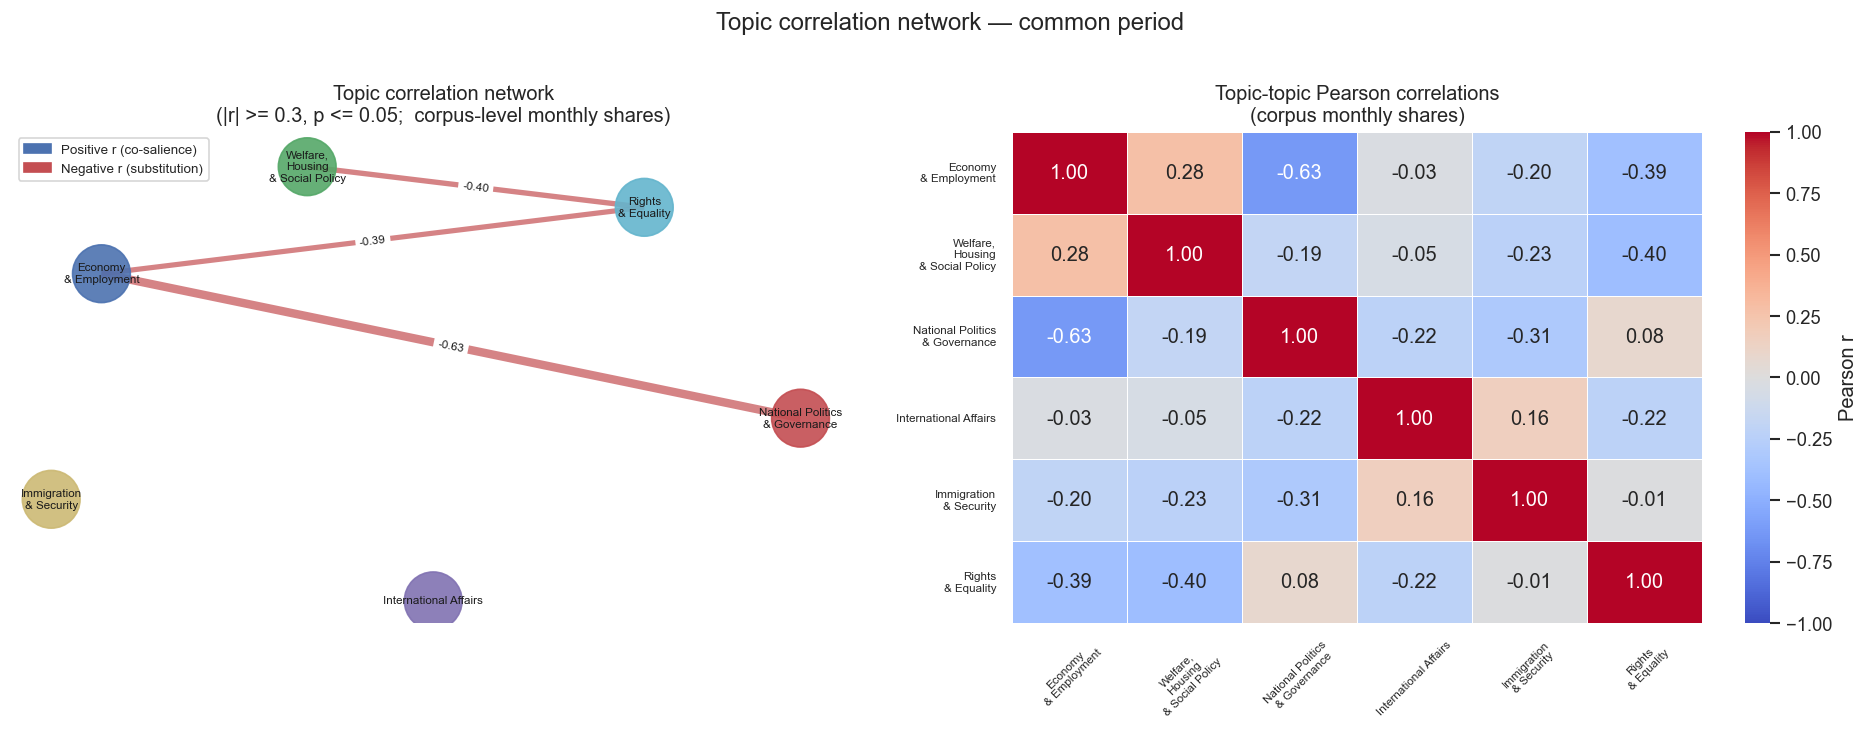

Significant correlations (|r| >= 0.30):
                           Topic A                          Topic B      r      p
  National Politics and Governance         Immigration and Security -0.308 0.0762
            Economy and Employment              Rights and Equality -0.389 0.0229
Welfare, Housing and Social Policy              Rights and Equality -0.400 0.0192
            Economy and Employment National Politics and Governance -0.630 0.0001


In [5]:
# --- Compute corpus-level monthly topic shares ---
monthly_totals = df_common.groupby(['month', 'topic']).size().unstack(fill_value=0)
monthly_totals = monthly_totals.reindex(columns=TOPIC_LABELS, fill_value=0)
monthly_share  = monthly_totals.div(monthly_totals.sum(axis=1), axis=0) * 100

MIN_R = 0.30
MAX_P = 0.05

topics_no_other = [t for t in TOPIC_LABELS if t != 'Other']

G_topic = nx.Graph()
G_topic.add_nodes_from(topics_no_other)

corr_records = []
for i, ta in enumerate(topics_no_other):
    for j, tb in enumerate(topics_no_other):
        if i >= j:
            continue
        a = monthly_share[ta].values
        b = monthly_share[tb].values
        r, p = pearsonr(a, b)
        corr_records.append({'Topic A': ta, 'Topic B': tb, 'r': round(r,3), 'p': round(p,4)})
        if abs(r) >= MIN_R and p <= MAX_P:
            G_topic.add_edge(ta, tb, weight=r, abs_weight=abs(r))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: network
ax = axes[0]
pos_topic = nx.spring_layout(G_topic, weight='abs_weight', seed=7, k=2.5)

node_colors_t = [TOPIC_COLORS[t] for t in G_topic.nodes()]
node_labels_t = {t: t.replace(' and ', '\n& ').replace(', ', ',\n')
                 for t in G_topic.nodes()}

nx.draw_networkx_nodes(G_topic, pos_topic, node_color=node_colors_t,
                       node_size=1200, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_topic, pos_topic, labels=node_labels_t,
                        font_size=7, ax=ax)

pos_edges = [(u, v) for u, v, d in G_topic.edges(data=True) if d['weight'] > 0]
neg_edges = [(u, v) for u, v, d in G_topic.edges(data=True) if d['weight'] < 0]
pos_widths = [abs(d['weight']) * 8 for u, v, d in G_topic.edges(data=True) if d['weight'] > 0]
neg_widths = [abs(d['weight']) * 8 for u, v, d in G_topic.edges(data=True) if d['weight'] < 0]

if pos_edges:
    nx.draw_networkx_edges(G_topic, pos_topic, edgelist=pos_edges,
                           width=pos_widths, edge_color='#4C72B0', alpha=0.7, ax=ax)
if neg_edges:
    nx.draw_networkx_edges(G_topic, pos_topic, edgelist=neg_edges,
                           width=neg_widths, edge_color='#C44E52', alpha=0.7, ax=ax)

edge_labels_t = {(u, v): f"{d['weight']:+.2f}" for u, v, d in G_topic.edges(data=True)}
nx.draw_networkx_edge_labels(G_topic, pos_topic, edge_labels=edge_labels_t,
                             font_size=7, ax=ax)

blue_patch = mpatches.Patch(color='#4C72B0', label='Positive r (co-salience)')
red_patch  = mpatches.Patch(color='#C44E52', label='Negative r (substitution)')
ax.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=8)
ax.set_axis_off()
ax.set_title('Topic correlation network\n'
             f'(|r| >= {MIN_R}, p <= {MAX_P};  corpus-level monthly shares)')

# Right: full correlation heatmap
ax2 = axes[1]
all_t = topics_no_other
full_corr = pd.DataFrame(np.eye(len(all_t)), index=all_t, columns=all_t)
for _, row in pd.DataFrame(corr_records).iterrows():
    full_corr.loc[row['Topic A'], row['Topic B']] = row['r']
    full_corr.loc[row['Topic B'], row['Topic A']] = row['r']

short_names = [t.replace(' and ', '\n& ').replace(', ', ',\n') for t in all_t]
sns.heatmap(full_corr.astype(float),
            xticklabels=short_names, yticklabels=short_names,
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r'}, ax=ax2)
ax2.set_title('Topic-topic Pearson correlations\n(corpus monthly shares)')
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Topic correlation network — common period', y=1.01)
plt.tight_layout()
plt.show()

sig = pd.DataFrame(corr_records).query('abs(r) >= @MIN_R').sort_values('r', ascending=False)
print('Significant correlations (|r| >= 0.30):')
print(sig.to_string(index=False))

This figure shows the correlation structure between topic time series during the common period. Each topic is represented by its monthly share in the corpus, and Pearson correlations are computed between topic pairs. In the network, an edge is shown when the absolute correlation is at least 0.30. Positive correlations would indicate that two topics tend to rise and fall together, while negative correlations indicate a substitution pattern: when one topic becomes more prominent, the other tends to decrease.

The most important relationship is the negative correlation between Economy and Employment and National Politics and Governance, with r = -0.630 and p = 0.0001. This is the strongest association in the figure. It suggests that months with a higher relative presence of economic and employment-related content tend to coincide with a lower relative presence of national political and institutional debate. In practical terms, this indicates a competition for agenda space between socio-economic issues and national political conflict.

Economy and Employment also shows a negative correlation with Rights and Equality, with r = -0.389 and p = 0.0229. This means that these two topics do not usually increase at the same time in the corpus. When economic and labour issues receive more attention, rights-related topics tend to occupy a smaller share of the discussion, and vice versa.

A similar pattern appears between Welfare, Housing and Social Policy and Rights and Equality, with r = -0.400 and p = 0.0192. Although these two categories may seem conceptually close, the temporal pattern suggests that they peak in different moments. This may indicate that social policy debates and rights-related debates are activated by different political events or communicative contexts.

The pair National Politics and Governance and Immigration and Security also shows a negative correlation, with r = -0.308. However, its p-value is 0.0762, which means that this relationship does not reach the conventional 0.05 significance threshold. For this reason, it should be interpreted with caution. It may suggest a possible substitution pattern, but the evidence is weaker than for the other correlations.

The network contains only negative edges, which means that the strongest temporal relationships in this analysis are not based on co-salience, but on substitution. In other words, the main topics do not tend to rise together. Instead, the data suggests that certain topics compete for attention within the monthly political agenda. The clearest example is the trade-off between Economy and Employment and National Politics and Governance.

The heatmap complements the network by showing all pairwise correlations, including weaker ones. Most correlations are close to zero or moderately negative, which suggests that the corpus is structured around changing thematic priorities rather than stable topic clusters. Some topics, such as International Affairs and Immigration and Security, appear relatively independent from the rest, since they do not show strong significant correlations with other categories.

The topic correlation network indicates that topic evolution in the corpus is mainly characterized by agenda substitution. When some topics gain visibility, especially Economy and Employment, other topics such as National Politics and Governance or Rights and Equality tend to lose relative weight. This supports the idea that political communication is event-driven and that different issue areas compete for prominence over time.

## Stance-polarization heatmap

For each combination of politician and topic, the positivity index is computed
as the percentage of In favor tweets minus the percentage of Against tweets among
all tweets by that politician on that topic during the common period. Positive
values indicate a net affirmative posture; negative values indicate a
predominantly oppositional posture.

Each cell in the heatmap is annotated with three pieces of information: the
positivity index in percentage points, the first three characters of the dominant
stance label, and the total number of tweets in that cell. Cells with fewer than
10 tweets are marked with an asterisk to signal that the percentage is based on
a small count and should be interpreted with caution. The Other topic category
is excluded because its heterogeneous content makes stance comparisons
less meaningful.

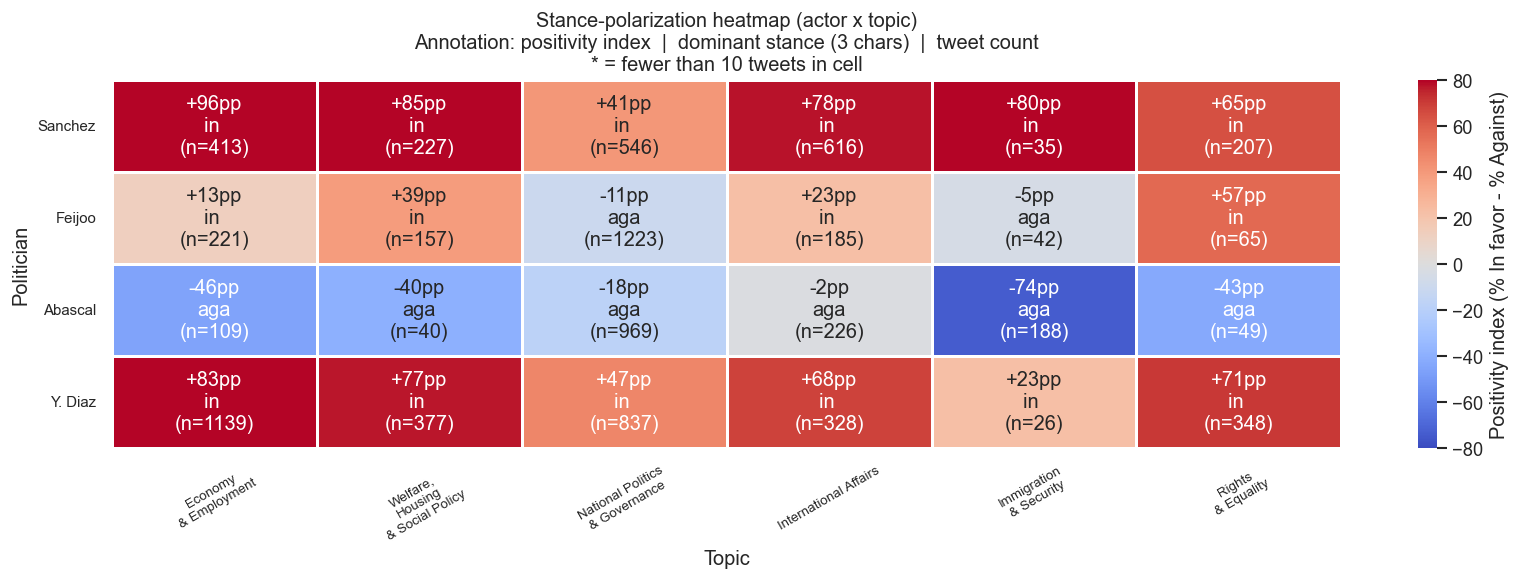

In [6]:
TOPICS_POLAR = [t for t in TOPIC_LABELS if t != 'Other']
MIN_TWEETS   = 10

rows = []
for pol in POLITICIAN_ORDER:
    for topic in TOPICS_POLAR:
        sub = df_common[(df_common['politician'] == pol) &
                        (df_common['topic'] == topic)]
        n = len(sub)
        if n == 0:
            rows.append({'politician': pol, 'topic': topic,
                         'positivity': np.nan, 'n': 0, 'dominant': ''})
            continue
        pct = sub['stance'].value_counts(normalize=True) * 100
        inf = pct.get('In favor', 0)
        agt = pct.get('Against', 0)
        dominant = sub['stance'].value_counts().idxmax()
        rows.append({'politician': pol, 'topic': topic,
                     'positivity': inf - agt, 'n': n,
                     'dominant': dominant})

polar_df = pd.DataFrame(rows)
pivot_pos = polar_df.pivot(index='politician', columns='topic', values='positivity')
pivot_n   = polar_df.pivot(index='politician', columns='topic', values='n')
pivot_dom = polar_df.pivot(index='politician', columns='topic', values='dominant')

pivot_pos = pivot_pos.reindex(index=POLITICIAN_ORDER, columns=TOPICS_POLAR)
pivot_n   = pivot_n.reindex(index=POLITICIAN_ORDER, columns=TOPICS_POLAR)
pivot_dom = pivot_dom.reindex(index=POLITICIAN_ORDER, columns=TOPICS_POLAR)

# Build annotation matrix
annot = pd.DataFrame('', index=POLITICIAN_ORDER, columns=TOPICS_POLAR)
for pol in POLITICIAN_ORDER:
    for topic in TOPICS_POLAR:
        n   = pivot_n.loc[pol, topic]
        pos = pivot_pos.loc[pol, topic]
        dom = pivot_dom.loc[pol, topic]
        if n == 0:
            annot.loc[pol, topic] = 'n/a'
        else:
            star = '*' if n < MIN_TWEETS else ''
            annot.loc[pol, topic] = f"{pos:+.0f}pp\n{dom[:3].lower()}{star}\n(n={n})"

yticklabels = [POLITICIAN_LABELS[p] for p in POLITICIAN_ORDER]
xticklabels = [t.replace(' and ', '\n& ').replace(', ', ',\n') for t in TOPICS_POLAR]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_pos.astype(float),
            xticklabels=xticklabels, yticklabels=yticklabels,
            annot=annot.values, fmt='',
            cmap='coolwarm', center=0, vmin=-80, vmax=80,
            linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'Positivity index (% In favor - % Against)'},
            ax=ax)
ax.set_title(
    'Stance-polarization heatmap (actor x topic)\n'
    'Annotation: positivity index  |  dominant stance (3 chars)  |  tweet count\n'
    '* = fewer than 10 tweets in cell')
ax.set_xlabel('Topic')
ax.set_ylabel('Politician')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

This heatmap shows the stance balance for each politician-topic combination. The value in each cell is a positivity index, calculated as the percentage of tweets classified as In favor minus the percentage of tweets classified as Against. Positive values indicate that supportive tweets are more frequent than critical tweets, while negative values indicate that critical tweets are more frequent. Each cell also reports the dominant stance and the number of tweets in that actor-topic combination.

The figure reveals clear differences between government actors and opposition actors. Sánchez and Yolanda Díaz show mostly positive values across topics, meaning that their tweets are generally classified as supportive rather than critical. This is consistent with their institutional and governmental roles, since a large part of their communication is likely to present, defend or promote policies, actions and political positions.

Sánchez shows especially high positivity in Economy and Employment (+96 pp), Welfare, Housing and Social Policy (+85 pp), Immigration and Security (+80 pp) and International Affairs (+78 pp). These values suggest that his communication in these areas is mainly framed in supportive terms. However, National Politics and Governance has a lower positivity index (+41 pp), even though it contains a large number of tweets (n = 546). This indicates that national political debate is a more contested space, with more criticism or confrontation than other policy areas.

Yolanda Díaz also presents a strongly positive profile. Her highest values appear in Economy and Employment (+83 pp), Welfare, Housing and Social Policy (+77 pp), Rights and Equality (+71 pp) and International Affairs (+68 pp). This pattern fits her thematic profile, which is more focused on labour, social policy and rights-related issues. National Politics and Governance is again less positive (+47 pp), suggesting that institutional or party-political debate introduces more conflict than socio-economic policy communication.

Feijóo shows a more mixed stance profile. Some topics have positive values, such as Rights and Equality (+57 pp), Welfare, Housing and Social Policy (+39 pp) and International Affairs (+23 pp). However, National Politics and Governance is slightly negative (-11 pp) and Immigration and Security is also slightly negative (-5 pp). This suggests that his communication is more critical in the areas most connected to government performance, institutional conflict and security-related debate. The very large number of tweets in National Politics and Governance (n = 1223) makes this cell especially important for interpreting his general stance profile.

Abascal presents the most negative stance profile in the heatmap. All his topic cells are negative, with especially strong negative values in Immigration and Security (-74 pp), Economy and Employment (-46 pp), Rights and Equality (-43 pp) and Welfare, Housing and Social Policy (-40 pp). This indicates that his communication is predominantly oppositional or critical across the main issue areas. National Politics and Governance is also negative (-18 pp), but less strongly than some policy-specific categories.

The strongest contrast appears in Immigration and Security. Sánchez shows a highly positive value (+80 pp), while Abascal shows a strongly negative value (-74 pp). This suggests that the same thematic area is framed in very different ways by different actors. For Sánchez, the topic is more often associated with support or institutional framing, while for Abascal it is mainly associated with criticism and opposition.

The heatmap also shows that topic-level stance depends strongly on the actor. For example, Economy and Employment is highly positive for Sánchez (+96 pp) and Yolanda Díaz (+83 pp), but negative for Abascal (-46 pp). This means that the same topic can play different communicative roles depending on the political actor: policy promotion for government actors and criticism for opposition actors.

Cells with fewer than 10 tweets should be interpreted with caution. In this figure, most cells have enough observations, but some actor-topic combinations are relatively small, such as Sánchez on Immigration and Security (n = 35), Yolanda Díaz on Immigration and Security (n = 26), and Abascal on Welfare, Housing and Social Policy (n = 40). These values are still useful descriptively, but they should not be overinterpreted.

## Temporal network snapshots

The politician similarity network is recomputed separately for three political
periods to track whether agenda convergence or divergence evolves over time.
The same fixed node positions are used in every panel so that changes in edge
thickness can be compared visually across periods without spatial ambiguity.
An actor is included in a period only if they published at least 30 tweets
during that window.

The three periods are chosen to reflect structurally different moments in the
Spanish political cycle:

| Period | Dates | Political context |
|--------|-------|-------------------|
| Pre-election | Apr 2022 - Jun 2023 | Pre-electoral campaign phase |
| Electoral and investiture | Jul 2023 - Mar 2024 | General election and investiture negotiations |
| Post-investiture | Apr 2024 - Jan 2025 | Governing coalition consolidation |

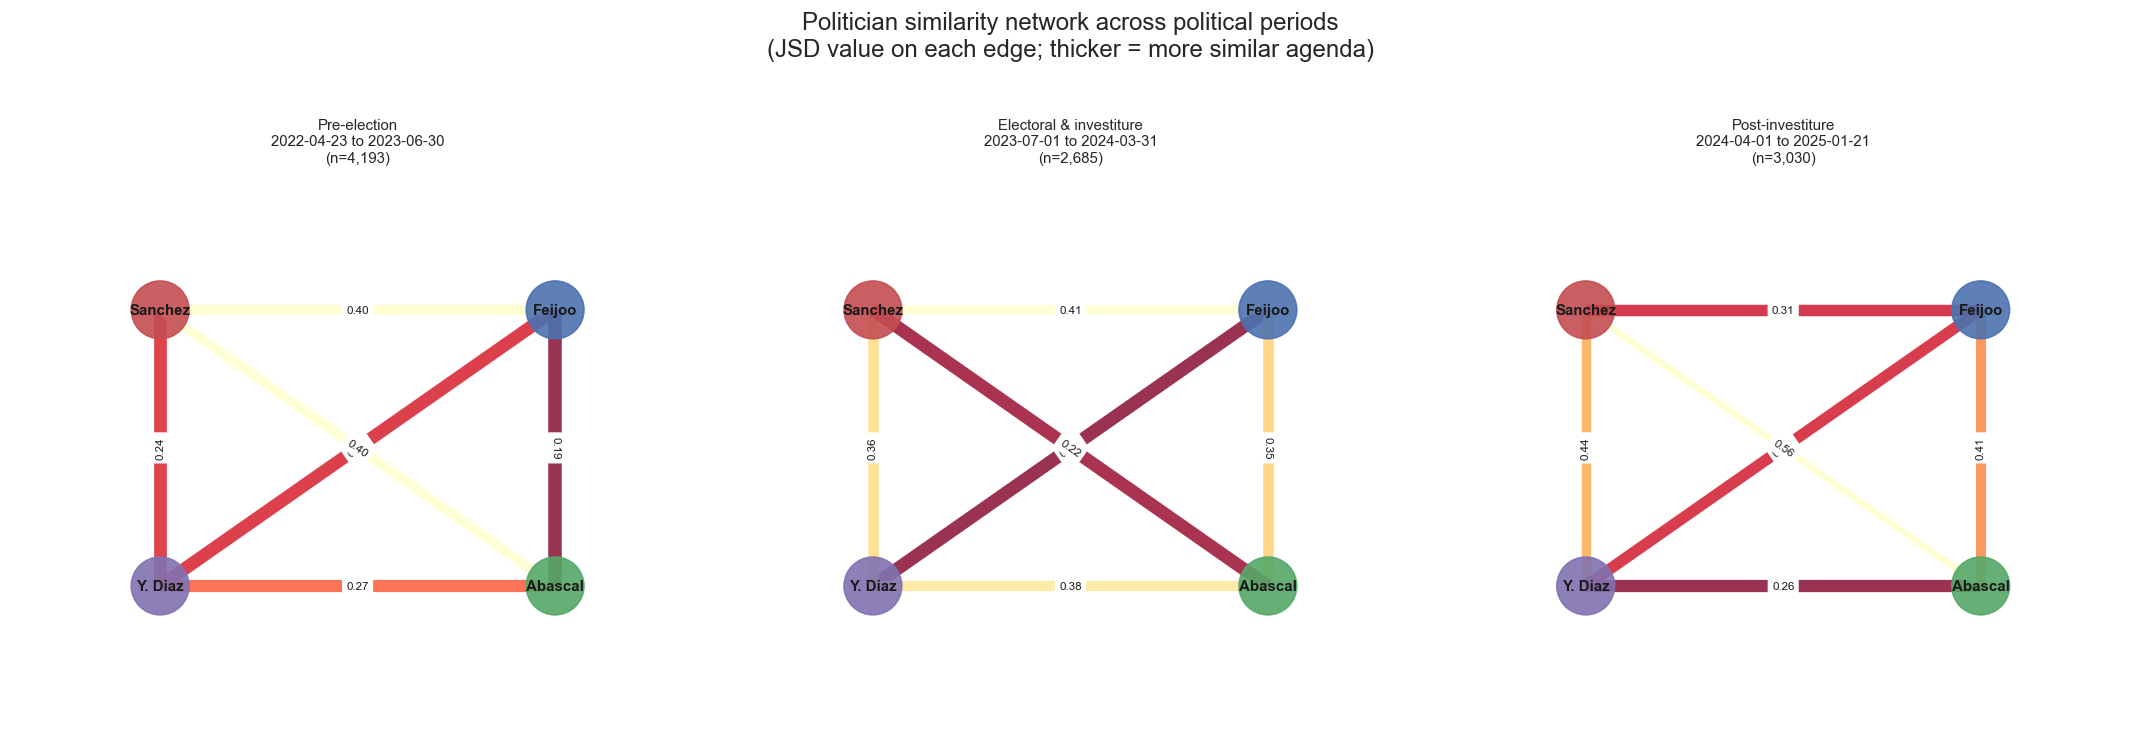

In [7]:
PERIODS = [
    ('Pre-election',        pd.Timestamp('2022-04-23'), pd.Timestamp('2023-06-30')),
    ('Electoral & investiture', pd.Timestamp('2023-07-01'), pd.Timestamp('2024-03-31')),
    ('Post-investiture',    pd.Timestamp('2024-04-01'), pd.Timestamp('2025-01-21')),
]

def jsd_network_for_period(df, start, end):
    sub = df[(df['date'] >= start) & (df['date'] <= end)]
    # Only keep actors with at least 30 tweets in period
    counts = sub['politician'].value_counts()
    active = counts[counts >= 30].index.tolist()
    if len(active) < 2:
        return None, None
    pct = pd.crosstab(sub.loc[sub['politician'].isin(active), 'politician'],
                      sub.loc[sub['politician'].isin(active), 'topic'],
                      normalize='index') * 100
    pct = pct.reindex(columns=TOPIC_LABELS, fill_value=0)
    P   = pct.values / 100
    jsd = pd.DataFrame(index=active, columns=active, dtype=float)
    for i, a in enumerate(active):
        for j, b in enumerate(active):
            jsd.loc[a, b] = jensenshannon(P[i], P[j], base=2)
    return active, jsd

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Fixed positions so the same actor appears in the same spot across panels
fixed_pos = {
    'sanchezcastejon': (-0.8,  0.5),
    'NunezFeijoo':     ( 0.8,  0.5),
    'Santi_ABASCAL':   ( 0.8, -0.5),
    'Yolanda_Diaz_':   (-0.8, -0.5),
}

for ax, (label, start, end) in zip(axes, PERIODS):
    active, jsd = jsd_network_for_period(df_common, start, end)
    if active is None:
        ax.set_axis_off()
        ax.set_title(label)
        continue

    G_p = nx.Graph()
    G_p.add_nodes_from(active)
    for i in range(len(active)):
        for j in range(i+1, len(active)):
            d = float(jsd.iloc[i, j])
            G_p.add_edge(active[i], active[j], weight=1-d, jsd=d)

    pos_p = {a: fixed_pos[a] for a in active if a in fixed_pos}

    nc = [POLITICIAN_COLORS[p] for p in G_p.nodes()]
    nl = {p: POLITICIAN_LABELS[p] for p in G_p.nodes()}
    ew = [d['weight'] * 10 for _, _, d in G_p.edges(data=True)]
    ec = [d['weight'] for _, _, d in G_p.edges(data=True)]

    nx.draw_networkx_nodes(G_p, pos_p, node_color=nc,
                           node_size=1200, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G_p, pos_p, labels=nl,
                            font_size=9, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G_p, pos_p, width=ew,
                           edge_color=ec,
                           edge_cmap=plt.cm.YlOrRd,
                           alpha=0.8, ax=ax)
    el = {(u, v): f"{d['jsd']:.2f}" for u, v, d in G_p.edges(data=True)}
    nx.draw_networkx_edge_labels(G_p, pos_p, edge_labels=el,
                                 font_size=7, ax=ax)

    n_period = int(df_common[(df_common['date']>=start)&(df_common['date']<=end)]['politician'
               ].isin(active).sum())
    ax.set_title(f'{label}\n{start.date()} to {end.date()}\n(n={n_period:,})',
                 fontsize=9)
    ax.set_axis_off()
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.0, 1.0)

plt.suptitle('Politician similarity network across political periods\n'
             '(JSD value on each edge; thicker = more similar agenda)',
             y=1.02)
plt.tight_layout()
plt.show()

This figure compares how agenda similarity between political actors changes across three political periods: the pre-election period, the electoral and investiture period, and the post-investiture period. Each network uses Jensen-Shannon distance to compare the topic distribution of each pair of politicians. Lower JSD values indicate more similar agendas. In the graph, thicker edges represent stronger agenda similarity.

In the pre-election period, the closest pair is Sánchez and Yolanda Díaz, with a JSD of 0.24. This indicates a relatively high thematic similarity between the two government-side actors before the electoral cycle. Feijóo and Abascal also show a relatively close agenda, with a JSD of 0.19. This suggests that, before the election, the two opposition actors shared a strong thematic focus. The distance between Sánchez and Abascal is much higher, with a JSD of 0.40, indicating clear agenda divergence between these actors.

During the electoral and investiture period, the structure changes. The closest relation appears between Yolanda Díaz and Feijóo, with a JSD of 0.22. This may reflect a temporary convergence of agendas during the campaign and negotiation period, when different actors were responding to similar electoral and institutional events. Sánchez and Abascal also show a relatively close distance of 0.22, suggesting that the electoral context may have created temporary thematic overlap even between ideologically distant actors. At the same time, Sánchez and Feijóo show a higher distance of 0.41, meaning that their thematic agendas were less similar during this period.

In the post-investiture period, the network becomes more polarized again. Sánchez and Yolanda Díaz are the most similar pair, with a JSD of 0.44 in the visible edge labels of the network, while Feijóo and Abascal also remain relatively close with a JSD of 0.41. The strongest visible similarity appears between Sánchez and Feijóo, with a JSD of 0.31, suggesting some shared focus on national political issues after the investiture. However, the distance between Yolanda Díaz and Feijóo is much larger, with a JSD of 0.56, indicating a strong divergence in agenda priorities.

The evolution across periods suggests that agenda similarity is not fixed. It changes depending on the political context. During the electoral and investiture period, some unexpected cross-bloc similarities appear, probably because all actors are reacting to the same high-salience political events, such as elections, parliamentary negotiations and investiture debates. In the post-investiture period, the agenda structure becomes more clearly divided again, with actors returning to more distinctive thematic profiles.

The comparison also shows that political periods affect not only the volume of discussion, but also the relational structure between actors. The same politician can appear closer to different actors depending on the period analyzed. This supports the idea that political agendas in online communication are dynamic and event-driven, rather than stable across the full corpus.

## Summary

The thematic-graph analysis produces five complementary representations of the same underlying data, each emphasizing a different dimension of the political communication structure.

The bipartite user-topic network provides a direct view of the relationship between political actors and thematic categories. Feijoo and Abascal concentrate most of their communication in National Politics and Governance, with more than half of their tweets assigned to this category. Yolanda Diaz shows a more socio-economic profile, with Economy and Employment as her strongest connection. Sanchez presents a more diversified agenda, with a particularly strong link to International Affairs. These patterns suggest that the actors do not participate in the discussion structure in the same way: some agendas are highly concentrated around national political conflict, while others are more distributed across policy areas.

The politician agenda similarity network confirms that these thematic profiles are not isolated patterns. Using Jensen-Shannon distance between topic distributions, the closest pairs are Sanchez and Yolanda Diaz, and Feijoo and Abascal. This structure emerges without using party-affiliation information, which indicates that the topic distributions themselves are enough to recover a meaningful political bloc structure. The heatmap also shows that the greatest thematic divergence appears between Abascal and Yolanda Diaz, reflecting their different issue priorities.

The topic correlation network adds a temporal perspective to the analysis. Rather than showing strong co-salience between topics, the main significant relationships are negative. The strongest association is the negative correlation between Economy and Employment and National Politics and Governance, suggesting a substitution effect between socio-economic discussion and national political debate. Other negative relationships, such as those involving Rights and Equality, indicate that different issue areas tend to gain salience at different moments. This supports the idea that the political agenda is structured by competition between topics rather than by stable thematic clusters.

The stance-polarization heatmap shows that stance is both actor-dependent and topic-dependent. Sanchez and Yolanda Diaz display mostly positive values across topics, consistent with their governmental and policy-promoting roles. Abascal shows a predominantly oppositional profile across all thematic areas, especially in Immigration and Security. Feijoo occupies a more mixed position, with positive values in some policy areas but more critical values in National Politics and Governance and Immigration and Security. These results show that topic classification alone is not enough to describe the discussion structure, since the same topic can be framed very differently depending on the actor.

Finally, the temporal similarity snapshots show that agenda proximity between actors changes across political periods. The bloc structure is visible in some periods, but it is not completely stable. During electoral and investiture phases, temporary cross-actor similarities appear, probably because all actors respond to the same high-salience political events. In the post-investiture period, the network becomes more differentiated again. This confirms that political communication in the corpus is dynamic and event-driven, with actor relationships changing according to the political context.

Taken together, the graph-based analysis complements the temporal and classification results by making the structure of the discussion more interpretable. The networks show who talks about what, which actors have similar agendas, how topics compete for attention over time, and how stance varies across actor-topic combinations.
